In [2]:
!pip install librosa -q

In [ ]:
import numpy as np
import librosa
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


✅ Ready!


## 🔧 Core Functions

In [4]:
def get_embedding(audio_path, sr=22050):
    """
    Отримує embedding вектор з аудіо файлу.
    
    Args:
        audio_path: шлях до аудіо
        sr: sample rate
    
    Returns:
        np.array: embedding вектор (~100 dims)
    """
    # Завантажуємо аудіо
    y, _ = librosa.load(audio_path, sr=sr, mono=True)
    y = librosa.util.normalize(y)
    
    features = []
    
    # ========== CHROMA (тональність) ==========
    chroma = librosa.feature.chroma_cens(y=y, sr=sr)
    chroma_mean = np.mean(chroma, axis=1)      # [12]
    chroma_std = np.std(chroma, axis=1)        # [12]
    
    features.extend(chroma_mean)                # 12
    features.extend(chroma_std)                 # 12
    
    # Sorted chroma (OTI-інваріантний)
    features.extend(np.sort(chroma_mean)[::-1]) # 12
    
    # Інтервали між нотами (OTI-інваріантний)
    intervals = np.diff(chroma_mean)
    intervals = np.append(intervals, chroma_mean[0] - chroma_mean[-1])
    features.extend(intervals)                  # 12
    
    # ========== MFCC (тембр) ==========
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    features.extend(np.mean(mfcc, axis=1))      # 20
    features.extend(np.std(mfcc, axis=1))       # 20
    
    # ========== SPECTRAL ==========
    # Spectral contrast
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    features.extend(np.mean(contrast, axis=1))  # 7
    
    # Spectral centroid
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    features.append(np.mean(centroid))          # 1
    features.append(np.std(centroid))           # 1
    
    # Spectral rolloff
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    features.append(np.mean(rolloff))           # 1
    features.append(np.std(rolloff))            # 1
    
    # ========== TONNETZ (гармонія) ==========
    tonnetz = librosa.feature.tonnetz(y=y, sr=sr)
    features.extend(np.mean(tonnetz, axis=1))   # 6
    
    # ========== RHYTHM ==========
    # Tempo
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    tempo_norm = (tempo - 60) / 120  # Нормалізуємо до ~[-0.5, 1]
    features.append(float(tempo_norm))          # 1
    
    # Onset strength
    onset = librosa.onset.onset_strength(y=y, sr=sr)
    features.append(np.mean(onset))             # 1
    features.append(np.std(onset))              # 1
    
    # ========== ZERO CROSSING ==========
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    features.append(np.mean(zcr))               # 1
    features.append(np.std(zcr))                # 1
    
    # ========== RMS ENERGY ==========
    rms = librosa.feature.rms(y=y)[0]
    features.append(np.mean(rms))               # 1
    features.append(np.std(rms))                # 1
    
    # Total: 12+12+12+12 + 20+20 + 7+1+1+1+1 + 6 + 1+1+1 + 1+1 + 1+1 = 112 dims
    
    # Конвертуємо в numpy array
    embedding = np.array(features, dtype=np.float32)
    
    # Нормалізуємо (L2 norm)
    embedding = embedding / (np.linalg.norm(embedding) + 1e-8)
    
    return embedding

In [5]:
def get_segment_embeddings(audio_path, sr=22050, segment_sec=10.0, hop_sec=5.0):
    """
    Отримує embeddings для кожного сегменту пісні.
    Корисно для детекції часткового плагіату.
    
    Returns:
        embeddings: list of np.array
        timestamps: list of (start_sec, end_sec)
    """
    y, _ = librosa.load(audio_path, sr=sr, mono=True)
    y = librosa.util.normalize(y)
    
    segment_samples = int(segment_sec * sr)
    hop_samples = int(hop_sec * sr)
    
    embeddings = []
    timestamps = []
    
    start = 0
    while start + segment_samples <= len(y):
        segment = y[start:start + segment_samples]
        
        # Отримуємо embedding для сегменту
        emb = _get_segment_embedding(segment, sr)
        
        embeddings.append(emb)
        timestamps.append((start / sr, (start + segment_samples) / sr))
        
        start += hop_samples
    
    return embeddings, timestamps


def _get_segment_embedding(segment, sr):
    """Embedding для одного сегменту (спрощений)"""
    features = []
    
    # Chroma
    chroma = librosa.feature.chroma_cens(y=segment, sr=sr)
    features.extend(np.mean(chroma, axis=1))   # 12
    
    # MFCC
    mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=13)
    features.extend(np.mean(mfcc, axis=1))     # 13
    
    # Spectral
    contrast = librosa.feature.spectral_contrast(y=segment, sr=sr)
    features.extend(np.mean(contrast, axis=1)) # 7
    
    # Tonnetz
    tonnetz = librosa.feature.tonnetz(y=segment, sr=sr)
    features.extend(np.mean(tonnetz, axis=1))  # 6
    
    # Total: 38 dims
    embedding = np.array(features, dtype=np.float32)
    embedding = embedding / (np.linalg.norm(embedding) + 1e-8)
    
    return embedding

## 📊 Порівняння embeddings

In [6]:
def cosine_similarity(emb1, emb2):
    """Косинусна схожість (0 до 1)"""
    return float(np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2) + 1e-8))


def compare_songs(path1, path2):
    """
    Порівнює дві пісні.
    
    Returns:
        similarity: float (0-1)
    """
    print(f"Processing: {Path(path1).name}")
    emb1 = get_embedding(path1)
    
    print(f"Processing: {Path(path2).name}")
    emb2 = get_embedding(path2)
    
    similarity = cosine_similarity(emb1, emb2)
    
    return similarity


def compare_segments(path1, path2, threshold=0.85):
    """
    Порівнює сегменти двох пісень (для часткового плагіату).
    """
    print(f"Processing segments: {Path(path1).name}")
    emb1_list, ts1 = get_segment_embeddings(path1)
    
    print(f"Processing segments: {Path(path2).name}")
    emb2_list, ts2 = get_segment_embeddings(path2)
    
    print(f"\nComparing {len(emb1_list)} x {len(emb2_list)} segments...")
    
    # Матриця схожості
    n1, n2 = len(emb1_list), len(emb2_list)
    matrix = np.zeros((n1, n2))
    
    for i in range(n1):
        for j in range(n2):
            matrix[i, j] = cosine_similarity(emb1_list[i], emb2_list[j])
    
    # Найкращі збіги
    matches = []
    for i in range(n1):
        best_j = int(np.argmax(matrix[i, :]))
        best_sim = matrix[i, best_j]
        matches.append({
            'query_segment': i,
            'query_time': ts1[i],
            'ref_segment': best_j,
            'ref_time': ts2[best_j],
            'similarity': best_sim,
            'is_match': best_sim >= threshold
        })
    
    n_matches = sum(1 for m in matches if m['is_match'])
    
    return {
        'matrix': matrix,
        'matches': matches,
        'n_matches': n_matches,
        'n_total': n1,
        'match_ratio': n_matches / n1 if n1 > 0 else 0
    }

## 💾 База embeddings

In [7]:
class EmbeddingDatabase:
    """
    База embeddings для швидкого пошуку схожих пісень.
    """
    
    def __init__(self):
        self.embeddings = {}  # {'name': embedding}
    
    def add(self, name, audio_path):
        """Додає пісню в базу"""
        print(f"Adding: {name}")
        emb = get_embedding(audio_path)
        self.embeddings[name] = emb
        print(f"  ✓ Added ({len(emb)} dims)")
    
    def add_embedding(self, name, embedding):
        """Додає готовий embedding"""
        self.embeddings[name] = embedding
    
    def search(self, query_embedding, top_k=5):
        """Знаходить top_k найсхожіших"""
        results = []
        for name, emb in self.embeddings.items():
            sim = cosine_similarity(query_embedding, emb)
            results.append((name, sim))
        
        results.sort(key=lambda x: x[1], reverse=True)
        return results[:top_k]
    
    def search_by_file(self, audio_path, top_k=5):
        """Пошук по аудіо файлу"""
        query_emb = get_embedding(audio_path)
        return self.search(query_emb, top_k)
    
    def find_plagiarism(self, audio_path, threshold=0.80):
        """Знаходить можливий плагіат"""
        results = self.search_by_file(audio_path, top_k=len(self.embeddings))
        return [(name, sim) for name, sim in results if sim >= threshold]
    
    def save(self, filepath):
        """Зберігає базу"""
        np.savez(filepath, **self.embeddings)
        print(f"Saved {len(self.embeddings)} embeddings to {filepath}")
    
    def load(self, filepath):
        """Завантажує базу"""
        data = np.load(filepath)
        self.embeddings = {name: data[name] for name in data.files}
        print(f"Loaded {len(self.embeddings)} embeddings")
    
    def __len__(self):
        return len(self.embeddings)

---
## 🧪 Тест

In [8]:
import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

# =========================
# 1) НАЛАШТУВАННЯ ШЛЯХІВ
# =========================
ORIGINAL_DIR   = Path("/Users/ulanagusar/Desktop/ML_week-2026/smp_dataset/original")
COMPARISON_DIR = Path("/Users/ulanagusar/Desktop/ML_week-2026/smp_dataset/comparison")

# Якщо ти запускаєш у Colab/ноутбуці де CSV уже змонтований:
CSV_PATH = Path("/Users/ulanagusar/Desktop/ML_week-2026/smp_dataset/song_pairs.csv")  # <- у тебе є такий файл
# Якщо локально на Mac — зміни на свій шлях:
# CSV_PATH = Path("/Users/ulanagusar/Desktop/ML_week-2026/MusicPlagiarismDetection/song_pairs.csv")

OUT_CSV = Path("retrieval_results.csv")

# =========================
# 2) ДОПОМІЖНІ ФУНКЦІЇ
# =========================
def norm_name(x: str) -> str:
    """
    Уніфікує назву для матчінгу між CSV та файлами:
    - lower
    - прибирає розширення
    - нормалізує пробіли/підкреслення
    """
    x = Path(str(x)).name  # якщо прийде шлях
    x = re.sub(r"\.(wav|mp3|flac)$", "", x, flags=re.IGNORECASE)
    x = x.lower().strip()
    x = x.replace("’", "'").replace("`", "'")
    x = re.sub(r"[_\s]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def l2_normalize(v: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    n = float(np.linalg.norm(v))
    if n < eps:
        return v
    return v / n

def list_audio_files(folder: Path):
    return sorted([p for p in folder.rglob("*.wav") if p.is_file()])

# =========================
# 3) ЗАВАНТАЖЕННЯ GT ПАР З CSV
# =========================
pairs = pd.read_csv(CSV_PATH)

# Підлаштуй назви колонок, якщо вони інші.
# Я орієнтуюсь на типові: ori_title, comp_title (+ можливо pair_number)
if not {"ori_title", "comp_title"}.issubset(set(pairs.columns)):
    raise ValueError(f"У CSV нема колонок ori_title/comp_title. Є: {list(pairs.columns)}")

gt_map = {}  # comp_norm -> set(ori_norm) (раптом кілька валідних оригіналів)
for _, r in pairs.iterrows():
    comp = norm_name(r["comp_title"])
    ori  = norm_name(r["ori_title"])
    gt_map.setdefault(comp, set()).add(ori)

# =========================
# 4) ЕМБЕДИНГИ ДЛЯ ORIGINAL + ІНДЕКС (FAISS якщо є)
# =========================
orig_files = list_audio_files(ORIGINAL_DIR)
comp_files = list_audio_files(COMPARISON_DIR)

print(f"Original files:   {len(orig_files)}")
print(f"Comparison files: {len(comp_files)}")

# ---- Рахуємо embeddings для original
orig_names = [p.name for p in orig_files]
orig_norms = [norm_name(p.name) for p in orig_files]

orig_embs = []
for p in tqdm(orig_files, desc="Embedding original"):
    e = get_embedding(str(p))              # <-- твоя функція
    e = np.asarray(e, dtype=np.float32).reshape(-1)
    e = l2_normalize(e)
    orig_embs.append(e)

orig_embs = np.vstack(orig_embs).astype(np.float32)  # (N, D)
D = orig_embs.shape[1]
print("Original embeddings:", orig_embs.shape)

# ---- Будуємо пошук top-1
use_faiss = True
try:
    import faiss
    index = faiss.IndexFlatIP(D)  # inner product == cosine, якщо L2-нормалізовано
    index.add(orig_embs)
except Exception as ex:
    print("FAISS недоступний, перейду на numpy brute-force. Причина:", ex)
    use_faiss = False

def top1_search(query_emb: np.ndarray):
    """Повертає (best_idx, best_sim)."""
    q = np.asarray(query_emb, dtype=np.float32).reshape(1, -1)
    if use_faiss:
        sims, idxs = index.search(q, 1)
        return int(idxs[0, 0]), float(sims[0, 0])
    # brute-force cosine (бо нормалізовано -> dot)
    sims = (orig_embs @ q.T).reshape(-1)
    best = int(np.argmax(sims))
    return best, float(sims[best])

# =========================
# 5) ПРОГІН: comparison -> nearest original, перевірка по CSV
# =========================
rows = []
correct = 0
has_gt = 0

for p in tqdm(comp_files, desc="Query comparison"):
    comp_name = p.name
    comp_key  = norm_name(comp_name)

    q = get_embedding(str(p))  # <-- твоя функція
    q = np.asarray(q, dtype=np.float32).reshape(-1)
    q = l2_normalize(q)

    best_i, best_sim = top1_search(q)
    pred_orig_name = orig_names[best_i]
    pred_orig_key  = orig_norms[best_i]

    gt_set = gt_map.get(comp_key, None)
    is_in_csv = gt_set is not None
    is_correct = (pred_orig_key in gt_set) if is_in_csv else False

    if is_in_csv:
        has_gt += 1
        correct += int(is_correct)

    rows.append({
        "comp_file": comp_name,
        "pred_original": pred_orig_name,
        "similarity": best_sim,
        "in_song_pairs_csv": bool(is_in_csv),
        "is_correct": bool(is_correct),
        "gt_originals": "" if not is_in_csv else " | ".join(sorted(list(gt_set))[:10])
    })

res = pd.DataFrame(rows).sort_values(["is_correct", "similarity"], ascending=[True, False])

print("\n" + "="*60)
print("EVALUATION")
print("="*60)
print(f"Queries total: {len(comp_files)}")
print(f"Queries with GT in CSV: {has_gt}")
if has_gt > 0:
    acc = correct / has_gt
    print(f"Top-1 accuracy (only where GT exists): {acc*100:.2f}% ({correct}/{has_gt})")
else:
    print("Увага: жодного comparison-файлу не знайшлось у CSV по назві (перевір формат назв).")

# показати топ помилок
wrong = res[(res["in_song_pairs_csv"]) & (~res["is_correct"])].head(20)
if len(wrong) > 0:
    print("\nTop mismatches (first 20):")
    for _, r in wrong.iterrows():
        print(f"- comp: {r['comp_file']}")
        print(f"  pred: {r['pred_original']} (sim={r['similarity']:.3f})")
        print(f"  gt:   {r['gt_originals']}\n")

# зберегти результати
res.to_csv(OUT_CSV, index=False)
print(f"\nSaved: {OUT_CSV.resolve()}")


Original files:   19
Comparison files: 16


Embedding original: 100%|██████████| 19/19 [00:20<00:00,  1.06s/it]


Original embeddings: (19, 112)
FAISS недоступний, перейду на numpy brute-force. Причина: No module named 'faiss'


Query comparison: 100%|██████████| 16/16 [00:12<00:00,  1.24it/s]


EVALUATION
Queries total: 16
Queries with GT in CSV: 16
Top-1 accuracy (only where GT exists): 12.50% (2/16)

Top mismatches (first 20):
- comp: 진주-난 괜찮아.wav
  pred: Las Chicas Del Can El Negro No Puede.wav (sim=1.000)
  gt:   gloria gaynor-i will survive

- comp: _DANCE_ 싸이 _PSY_ - 챔피언.wav
  pred: The Monkees _ Mary_ Mary.wav (sim=1.000)
  gt:   crazy frog - axel f official video

- comp: Katy Perry - Dark Horse _Lyrics_ ft_ Juicy J.wav
  pred: September - Cry For You.wav (sim=1.000)
  gt:   joyful noise - official music video flame feat lecrae john reilly

- comp: Bandido - Vamos Amigos _Eurodance Version_.wav
  pred: Without you - Badfinger.wav (sim=1.000)
  gt:   official audio 이정현 lee jung-hyun - 와

- comp: Taylor Swift - Look What You Made Me Do.wav
  pred: September - Cry For You.wav (sim=1.000)
  gt:   right said fred - i m too sexy original mix - 2006 version

- comp: Céline Dion - The Power Of Love _Official Remastered HD Video_.wav
  pred: Major Lazer - Sua Cara _Feat_ Anit

In [9]:
# ЗМІНІТЬ НА ВАШІ ШЛЯХИ!

SONG1 = '/Users/ulanagusar/Desktop/ML_week-2026/MusicPlagiarismDetection/smp_dataset/comparison/Vanilla Ice - Ice Ice Baby _Official Music Video_.wav'
SONG2 = '/Users/ulanagusar/Desktop/ML_week-2026/MusicPlagiarismDetection/smp_dataset/original/Queen - Under Pressure _Official Video_.wav'
SONG3 = '/Users/ulanagusar/Desktop/ML_week-2026/MusicPlagiarismDetection/smp_dataset/original/The Gap Band - Oops Upside Your Head.wav'
# Тест отримання embedding
print("Getting embedding...")
emb = get_embedding(SONG1)
print(f"Embedding shape: {emb.shape}")
print(f"Embedding norm: {np.linalg.norm(emb):.4f}")  # Має бути ~1.0



# Порівняння двох пісень
print("="*50)
print("COMPARING TWO SONGS")
print("="*50)

emb1 = get_embedding(SONG1)
emb2 = get_embedding(SONG2)
emb3 = get_embedding(SONG3)

print(f"\nEmbedding dimensions: {len(emb1)}")

sim_1_2 = cosine_similarity(emb1, emb2)
sim_1_3 = cosine_similarity(emb1, emb3)
sim_2_3 = cosine_similarity(emb2, emb3)

print(f"\nSimilarities:")
print(f"  Song1 vs Song2: {sim_1_2:.3f}")
print(f"  Song1 vs Song3: {sim_1_3:.3f}")
print(f"  Song2 vs Song3: {sim_2_3:.3f}")


# Порівняння сегментів (для часткового плагіату)
print("="*50)
print("SEGMENT COMPARISON")
print("="*50)

result = compare_segments(SONG1, SONG2, threshold=0.80)

print(f"\nMatched segments: {result['n_matches']}/{result['n_total']}")
print(f"Match ratio: {result['match_ratio']*100:.1f}%")

print("\nTop matches:")
for m in sorted(result['matches'], key=lambda x: x['similarity'], reverse=True)[:5]:
    status = "✓" if m['is_match'] else " "
    print(f"  {status} Query {m['query_time'][0]:.1f}-{m['query_time'][1]:.1f}s → "
          f"Ref {m['ref_time'][0]:.1f}-{m['ref_time'][1]:.1f}s "
          f"(sim={m['similarity']:.3f})")

Getting embedding...
Embedding shape: (112,)
Embedding norm: 1.0000
COMPARING TWO SONGS

Embedding dimensions: 112

Similarities:
  Song1 vs Song2: 0.989
  Song1 vs Song3: 0.989
  Song2 vs Song3: 0.972
SEGMENT COMPARISON
Processing segments: Vanilla Ice - Ice Ice Baby _Official Music Video_.wav
Processing segments: Queen - Under Pressure _Official Video_.wav

Comparing 7 x 3 segments...

Matched segments: 6/7
Match ratio: 85.7%

Top matches:
  ✓ Query 30.0-40.0s → Ref 10.0-20.0s (sim=0.967)
  ✓ Query 25.0-35.0s → Ref 10.0-20.0s (sim=0.962)
  ✓ Query 20.0-30.0s → Ref 10.0-20.0s (sim=0.951)
  ✓ Query 10.0-20.0s → Ref 10.0-20.0s (sim=0.941)
  ✓ Query 15.0-25.0s → Ref 10.0-20.0s (sim=0.932)


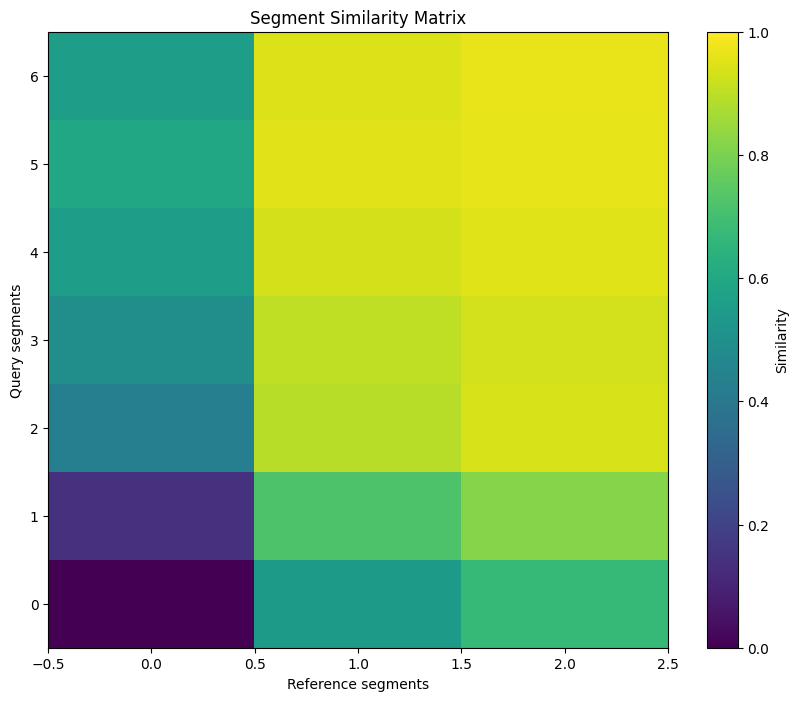

In [10]:
# Візуалізація матриці схожості сегментів
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(result['matrix'], aspect='auto', origin='lower', cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='Similarity')
plt.xlabel('Reference segments')
plt.ylabel('Query segments')
plt.title('Segment Similarity Matrix')
plt.show()

---
## 📚 Робота з базою

In [11]:
# Створюємо базу оригіналів
db = EmbeddingDatabase()

# Додаємо пісні (змініть на ваші)
# db.add('Queen - Under Pressure', '/path/to/queen.wav')
# db.add('Michael Jackson - Billie Jean', '/path/to/mj.wav')
# db.add('The Beatles - Yesterday', '/path/to/beatles.wav')

print(f"Database size: {len(db)}")

Database size: 0


In [12]:
# Пошук плагіату
# matches = db.find_plagiarism('/path/to/suspicious.wav', threshold=0.80)

# if matches:
#     print("🚨 Possible plagiarism found:")
#     for name, sim in matches:
#         print(f"  {name}: {sim:.3f}")
# else:
#     print("✅ No plagiarism detected")

In [13]:
# Збереження/завантаження бази
# db.save('music_embeddings.npz')
# db.load('music_embeddings.npz')

---
## 💡 Підсумок

### Embedding складається з:

| Feature | Dims | Що показує |
|---------|------|------------|
| Chroma mean | 12 | Які ноти найчастіше |
| Chroma std | 12 | Варіативність нот |
| Chroma sorted | 12 | OTI-інваріантний профіль |
| Chroma intervals | 12 | OTI-інваріантні інтервали |
| MFCC mean | 20 | Тембр (усереднений) |
| MFCC std | 20 | Варіативність тембру |
| Spectral contrast | 7 | Яскравість звуку |
| Spectral centroid | 2 | "Центр" спектру |
| Spectral rolloff | 2 | Верхня межа спектру |
| Tonnetz | 6 | Гармонічні відношення |
| Tempo | 1 | Темп |
| Onset | 2 | Сила атак |
| ZCR | 2 | Шумність |
| RMS | 2 | Гучність |
| **Total** | **~112** | |

### Використання:

```python
# Отримати embedding
emb = get_embedding('song.wav')

# Порівняти
sim = cosine_similarity(emb1, emb2)

# База
db = EmbeddingDatabase()
db.add('song', 'song.wav')
db.save('database.npz')
```